# Data Science Skill Clustering for Curriculum Design

**Dataset:** Web-scraped job postings from Indeed.com — Canadian, US, and remote data science roles.

**Objective:** Cluster 14 data science skills based on 9 derived features (frequency, salary, demand growth, difficulty, relevance, diversity metrics) to recommend a university course curriculum.

**Methods:** Keyword skill extraction · Hierarchical clustering (dendrogram) · K-Means clustering · PCA visualisation · LLM-assisted curriculum generation (OpenAI GPT)

---

In [1]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statistics import mean

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from collections import defaultdict

import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import openai

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## 1. Data Loading & Skill Extraction

**Dataset:** Web-scraped job postings from Indeed.com (Canada/US/Remote data science roles). Skills extracted from job descriptions using keyword matching.

In [2]:
results = pd.read_csv('Data_Scientist_Canada_US_Remote.csv', engine='python', on_bad_lines='skip')
results.rename(columns={'Job_Title': 'Title', 'Company_Name': 'Company', 'Job_Description': 'Descriptions'}, inplace=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

print(f'Total job postings: {len(results)}')
results.head(2)

Total job postings: 4408


Title                       Company                          Location  Rating                       Date                     Salary  \
0  Data Scientist [Post-Doc Research Fellow]  Edison Welding Institute Inc  Buffalo, NY 14211Â (Grider area)     NaN  EmployerActive 8 days ago   $75,000 - $90,000 a year   
1                             Data Scientist                    CVS Health                      New York, NY     NaN    PostedPosted 6 days ago  $80,500 - $170,000 a year   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          Links  \
0  https://www.indeed.com/pagead/clk?mo=r&ad=-6NYlbfkN0ADHDVjEfsdcfJKmuq_eAGE74sJSVkMxBxgW86bODLpADNMjOHkaxUCLot7aM3ULcyj5uZhOiL2RkJ0GWfFGqXaSu1cDMlSDM_4e24GYFsVqXhXmvXNNXh5UrgVk4oKxJvCz7bZydKEfJ4kmYjyzSV1gujMgVNkQkqxVsLLYT2PMJxYiZG8X12733fQfsYCf543h552HoSNf8IzKOM6mRxYgJUEsDDDhbwCWrg2xTXLnI7k363LhJL0bqyydK1AoPMaFUqrRajJnkBqP2IryVCyav2235YYMxQITxsHF_mTMzi07fUjCnAOXRoilZqbzGNzmn0MeIRPzOn7_s7HrzMkyQaBFnVH1k6Mz8a2b6ailKOIORz_aFf3TP28fmMAs5bK_4oM8p0yNIOgcz6EeSV2t3Iy-hUL9GTF3l3Jbdqj2d9G7d3s1_uCzI2cYLiTutVZ5c0l9hG8sBWA7YmbzFD0uNTq5-sYItTzRVBMkawNFNgNsYav__8AHSnQHwR04DdhtwrKD3kxs19HaE8twNIHXcKmWOcTgn5R6e9ThWf1zLVASID2K2R83PV2cFLkgKSA_aMKnQQakkI508ycy4Ut3egL8M0VB7Ke0AVOqTJHr_4HodN3w7vRRQtE4LvLt5rN-ZOCyOdyOIt7aMc9PjxPzPw7QMbhMvuOm-rw_wHJ3Wyhk0soMKnzVELyiDmYInI6Hv8klZvh0cSWfyzFvP5Wws5k6lz381up1eGOxVlutZ6paunCnUHj0OsQ2pWp5n09kqpM92IVMXsk65xU97DFYkMe-HELzZB93PrynqrYaq__o7CDb_8O6meqSClh2wSu0me56v38lrX8TNu6D89b&xkcb=SoAi-_M3HLh96_2eKh0LbzkdCdPP&p=0&fvj=0&vjs=3   
1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                https://www.indeed.com/rc/clk?jk=4b029f55b2180a81&fccid=be3b11aa573faee7&vjs=3   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

### 1.1 Skill Extraction

Keyword-based extraction for 14 skills across four categories: Programming (Python, MATLAB, Excel, SQL), Technical (Data Management, Big Data, ML, Modelling), Business (Project Management, Consulting, Negotiation), and Interpersonal (Teamwork, Creativity, Communication).

In [3]:
sskills = {'Python': [], 'Matlab': [], 'Excel': [], 'SQL': []}
tskills = {'Data Management': [], 'Big Data': [], 'Machine Learning': [], 'Modeling': []}
bskills = {'Project Management': [], 'Consulting': [], 'Negotiation': []}
pskills = {'Teamwork': [], 'Creativity': [], 'Communication': []}

for _, row in results.iterrows():
    t = str(row['Descriptions']).lower()

    sskills['Python'].append('1' if 'python' in t else '0')
    sskills['Matlab'].append('1' if 'matlab' in t else '0')
    sskills['Excel'].append('1' if any(x in t for x in ['excel ', 'excel,', 'excel.']) else '0')
    sskills['SQL'].append('1' if any(x in t for x in ['sql', 'structured quer', 'server']) else '0')

    tskills['Data Management'].append('1' if any(x in t for x in ['databas', 'data mana', 'data ha', 'data lak', 'data war', 'data eng', 'data proc']) else '0')
    tskills['Big Data'].append('1' if 'big data' in t else '0')
    tskills['Machine Learning'].append('1' if 'machine learning' in t else '0')
    tskills['Modeling'].append('1' if any(x in t for x in ['modeling', 'model']) else '0')

    bskills['Project Management'].append('1' if 'project management' in t else '0')
    bskills['Consulting'].append('1' if 'consulting' in t else '0')
    bskills['Negotiation'].append('1' if 'negotiation' in t else '0')

    pskills['Teamwork'].append('1' if 'teamwork' in t else '0')
    pskills['Creativity'].append('1' if any(x in t for x in ['creativit', 'creative', 'creat']) else '0')
    pskills['Communication'].append('1' if 'communication' in t else '0')

df1 = results[['Title', 'Company', 'Location', 'Descriptions']].copy()
res = pd.concat([df1, pd.DataFrame(sskills), pd.DataFrame(tskills), pd.DataFrame(bskills), pd.DataFrame(pskills)], axis=1)

df_summary = res.iloc[:, 4:].apply(pd.to_numeric)
a = df_summary.values

print({k: list(sskills[k]).count('1') for k in sskills})
print({k: list(tskills[k]).count('1') for k in tskills})
print({k: list(bskills[k]).count('1') for k in bskills})
print({k: list(pskills[k]).count('1') for k in pskills})
print(f'Matrix shape: {a.shape}')

{'Python': 1901, 'Matlab': 93, 'Excel': 659, 'SQL': 1957}
{'Data Management': 2060, 'Big Data': 459, 'Machine Learning': 1572, 'Modeling': 2399}
{'Project Management': 601, 'Consulting': 476, 'Negotiation': 136}
{'Teamwork': 286, 'Creativity': 3078, 'Communication': 2657}
Matrix shape: (4408, 14)


## 2. Hierarchical Clustering

In [4]:
D = np.zeros([a.shape[1], a.shape[1]])
for i in range(a.shape[1]):
    for j in range(a.shape[1]):
        intersection = np.sum(a[:, i] & a[:, j])
        union = np.sum(a[:, i] | a[:, j])
        D[i, j] = 1 - (intersection / union) if union != 0 else 1

Y = sch.linkage(D, method='average')

/tmp/ipykernel_727/3278821074.py:8: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Y = sch.linkage(D, method='average')


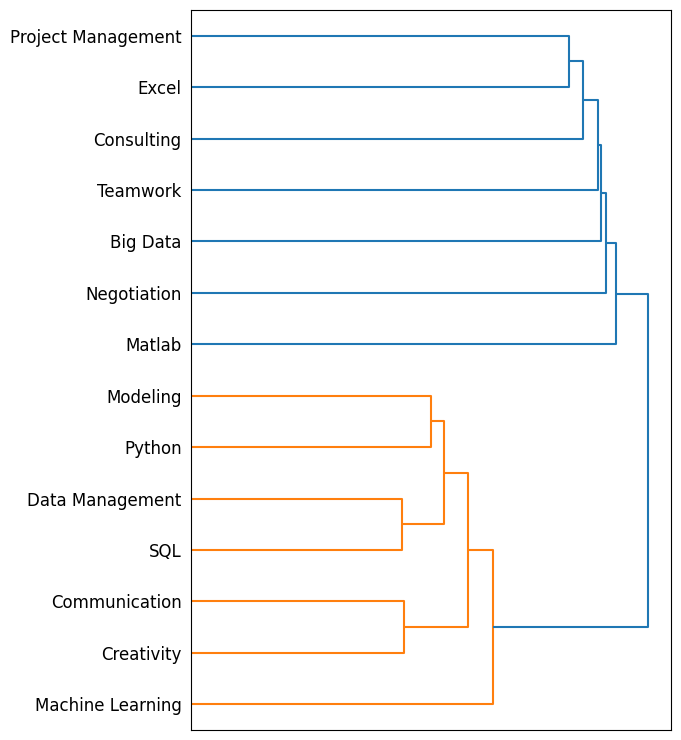

In [5]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_axes([0.1, 0.1, 0.4, 0.6])
Z = sch.dendrogram(Y, orientation='right')
labels = df_summary.columns[Z['leaves']]
ax.set_xticks([])
ax.set_yticklabels(labels)
plt.savefig('dendrogram.png', format='png', bbox_inches='tight')
plt.show()

### 2.1 Cluster Identification

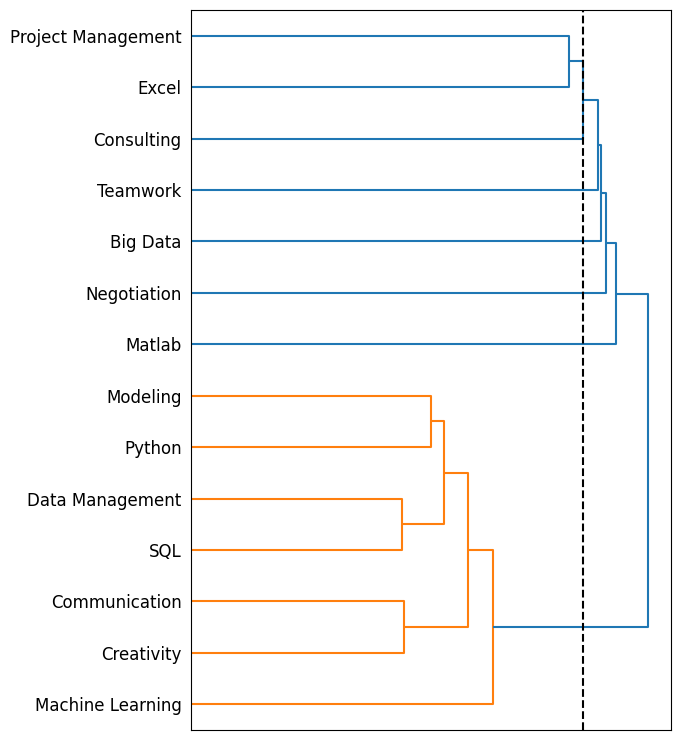

1 ['Machine Learning', 'Creativity', 'Communication', 'SQL', 'Data Management', 'Python', 'Modeling']
2 ['Excel', 'Project Management']
3 ['Consulting']
4 ['Teamwork']
5 ['Big Data']
6 ['Negotiation']
7 ['Matlab']
Auto-generated clusters: 7


In [6]:
max_d = 1.3

fig = plt.figure(figsize=(12, 12))
ax = fig.add_axes([0.1, 0.1, 0.4, 0.6])
Z = sch.dendrogram(Y, orientation='right')
labels = df_summary.columns[Z['leaves']]
ax.set_xticks([])
ax.set_yticklabels(labels)
plt.axvline(x=max_d * D.max(), c='k', linestyle='--')
plt.show()

lbs = sch.fcluster(Y, max_d * D.max(), 'distance')
clustr = lbs[Z['leaves']]

clust_skls = {k: [] for k in set(clustr)}
for j, lbl in enumerate(labels):
    clust_skls[clustr[j]].append(lbl)

for k, v in clust_skls.items():
    print(k, v)
print(f'Auto-generated clusters: {len(clust_skls)}')

### 2.2 Manual Cluster Refinement

Auto-generated clusters adjusted to ensure minimum 3 skills per cluster and meaningful groupings.

In [7]:
clust_skills = {
    0: ['Project Management', 'Negotiation', 'Consulting'],
    1: ['Machine Learning', 'Big Data', 'Data Management'],
    2: ['Excel', 'Matlab', 'SQL'],
    3: ['Python', 'Modeling'],
    4: ['Creativity', 'Communication', 'Teamwork'],
}

for cluster_id, skills in clust_skills.items():
    print(f'Cluster {cluster_id}: {skills}')
print(f'Manual clusters: {len(clust_skills)}')

Cluster 0: ['Project Management', 'Negotiation', 'Consulting']
Cluster 1: ['Machine Learning', 'Big Data', 'Data Management']
Cluster 2: ['Excel', 'Matlab', 'SQL']
Cluster 3: ['Python', 'Modeling']
Cluster 4: ['Creativity', 'Communication', 'Teamwork']
Manual clusters: 5


## 3. K-Means Clustering

### 3.1 Feature Engineering

Nine features extracted per skill from job postings: frequency, salary correlation, demand growth, difficulty, relevance, job role diversity, industry diversity, location diversity, and longevity.

In [8]:
import os

skills = ['Python', 'Matlab', 'Excel', 'SQL', 'Data Management', 'Big Data',
          'Machine Learning', 'Modeling', 'Project Management', 'Consulting',
          'Negotiation', 'Teamwork', 'Creativity', 'Communication']

job_descriptions = results['Descriptions'].dropna().tolist()

# Create the 'data' directory if it doesn't exist
os.makedirs('data', exist_ok=True)

# Use the already computed df_summary from cell-9a for skill frequencies
# df_summary contains columns for each skill with 0/1 indicating presence
skill_frequencies = df_summary.sum().to_dict()

frequency_df = pd.DataFrame(list(skill_frequencies.items()), columns=['Skill', 'Frequency'])
frequency_df.to_csv('data/skill_frequency.csv', index=False)
print(frequency_df)

                 Skill  Frequency
0               Python       1901
1               Matlab         93
2                Excel        659
3                  SQL       1957
4      Data Management       2060
5             Big Data        459
6     Machine Learning       1572
7             Modeling       2399
8   Project Management        601
9           Consulting        476
10         Negotiation        136
11            Teamwork        286
12          Creativity       3078
13       Communication       2657


In [9]:
def extract_salary(text):
    patterns = re.findall(r'\$?\d{2,3}(?:,\d{3})?(?:k|K)?', text)
    salaries = []
    for s in patterns:
        if 'k' in s.lower():
            salaries.append(float(s.lower().replace('k','').replace('$','').replace(',','')) * 1000)
        else:
            salaries.append(float(s.replace('$','').replace(',','')))
    return salaries

skill_salaries = {skill: [] for skill in skills}
for desc in job_descriptions:
    tokens = word_tokenize(desc.lower())
    for skill in skills:
        if skill.lower() in tokens:
            skill_salaries[skill].extend(extract_salary(desc))

average_salary_df = pd.DataFrame([
    {'Skill': s, 'Average Salary': mean(vals) if vals else 0}
    for s, vals in skill_salaries.items()
])
average_salary_df.to_csv('data/average_salary_per_skill.csv', index=False)
print(average_salary_df)

                 Skill  Average Salary
0               Python    40035.290796
1               Matlab    31089.192719
2                Excel    29679.693087
3                  SQL    37419.800767
4      Data Management        0.000000
5             Big Data        0.000000
6     Machine Learning        0.000000
7             Modeling    39447.931725
8   Project Management        0.000000
9           Consulting    32676.672175
10         Negotiation    21602.020378
11            Teamwork    31138.233581
12          Creativity    29244.647195
13       Communication    34406.230534


In [10]:
demand_keywords = {
    'increasing': ['increasing demand', 'high demand', 'rapid growth', 'rising need', 'expanding'],
    'stable':     ['stable demand', 'steady', 'consistent demand', 'unchanging'],
    'decreasing': ['declining demand', 'low demand', 'shrinking', 'reducing', 'falling'],
}

def detect_demand_growth(text, skill):
    for sentence in sent_tokenize(text.lower()):
        if skill.lower() in sentence:
            for growth, kws in demand_keywords.items():
                if any(kw in sentence for kw in kws):
                    return growth
    return 'N/A'

demand_growth = {}
for skill in skills:
    trends = [detect_demand_growth(d, skill) for d in job_descriptions]
    trends = [t for t in trends if t != 'N/A']
    demand_growth[skill] = max(set(trends), key=trends.count) if trends else 'N/A'

demand_growth_df = pd.DataFrame(list(demand_growth.items()), columns=['Skill', 'Demand Growth'])
demand_growth_df.to_csv('data/demand_growth_per_skill.csv', index=False)
print(demand_growth_df)

                 Skill Demand Growth
0               Python    increasing
1               Matlab           N/A
2                Excel    increasing
3                  SQL    decreasing
4      Data Management    decreasing
5             Big Data           N/A
6     Machine Learning    increasing
7             Modeling    decreasing
8   Project Management           N/A
9           Consulting    increasing
10         Negotiation           N/A
11            Teamwork    decreasing
12          Creativity           N/A
13       Communication    increasing


In [11]:
difficulty_keywords = {
    5: ['advanced', 'requires expertise', 'highly complex', 'challenging', 'difficult to master'],
    4: ['complex', 'requires training', 'intermediate', 'not easy'],
    3: ['moderate difficulty', 'requires some experience', 'mid-level', 'standard'],
    2: ['basic', 'entry-level', 'foundational', 'introductory'],
    1: ['easy to learn', 'simple', 'beginner-friendly', 'straightforward'],
}

def detect_difficulty(text, skill):
    for sentence in sent_tokenize(text.lower()):
        if skill.lower() in sentence:
            for score, kws in difficulty_keywords.items():
                if any(kw in sentence for kw in kws):
                    return score
    return None

difficulty_scores = {skill: [] for skill in skills}
for desc in job_descriptions:
    for skill in skills:
        d = detect_difficulty(desc, skill)
        if d is not None:
            difficulty_scores[skill].append(d)

difficulty_df = pd.DataFrame([
    {'Skill': s, 'Difficulty': mean(vals) if vals else 'N/A'}
    for s, vals in difficulty_scores.items()
])
difficulty_df.to_csv('data/difficulty_per_skill.csv', index=False)
print(difficulty_df)

                 Skill  Difficulty
0               Python    4.086268
1               Matlab    3.789474
2                Excel    4.042526
3                  SQL    4.079365
4      Data Management    3.810811
5             Big Data    4.275591
6     Machine Learning    4.239859
7             Modeling    4.187117
8   Project Management    3.887640
9           Consulting    4.367521
10         Negotiation    4.000000
11            Teamwork    3.787234
12          Creativity    4.206897
13       Communication    3.966234


In [12]:
relevance_keywords = {
    5: ['essential', 'critical', 'must-have', 'required', 'key skill'],
    4: ['preferred', 'important', 'highly desired'],
    3: ['useful', 'beneficial', 'advantageous'],
    2: ['optional', 'nice-to-have', 'not mandatory'],
    1: ['minor', 'not relevant', 'unimportant'],
}

def detect_relevance(text, skill):
    for sentence in sent_tokenize(text.lower()):
        if skill.lower() in sentence:
            for score, kws in relevance_keywords.items():
                if any(kw in sentence for kw in kws):
                    return score
    return None

relevance_scores = {skill: [] for skill in skills}
for desc in job_descriptions:
    for skill in skills:
        r = detect_relevance(desc, skill)
        if r is not None:
            relevance_scores[skill].append(r)

relevance_df = pd.DataFrame([
    {'Skill': s, 'Relevance': mean(vals) if vals else 'N/A'}
    for s, vals in relevance_scores.items()
])
relevance_df.to_csv('data/relevance_per_skill.csv', index=False)
print(relevance_df)

                 Skill  Relevance
0               Python   4.601307
1               Matlab   4.000000
2                Excel   4.685962
3                  SQL   4.631250
4      Data Management   4.776978
5             Big Data   4.612403
6     Machine Learning   4.583960
7             Modeling   4.587189
8   Project Management   4.664921
9           Consulting   4.596639
10         Negotiation   4.895833
11            Teamwork   4.666667
12          Creativity   4.757576
13       Communication   4.627876


In [13]:
job_roles = ['Data Scientist', 'Data Analyst', 'Machine Learning Engineer',
             'Business Analyst', 'Project Manager', 'Consultant', 'Researcher']

job_role_diversity = {skill: set() for skill in skills}
for desc in job_descriptions:
    tokens = word_tokenize(desc.lower())
    for skill in skills:
        if skill.lower() in tokens:
            for role in job_roles:
                if role.lower() in desc.lower():
                    job_role_diversity[skill].add(role)

job_role_df = pd.DataFrame([
    {'Skill': s, 'Job Role Diversity': len(roles)}
    for s, roles in job_role_diversity.items()
])
job_role_df.to_csv('data/job_role_diversity.csv', index=False)
print(job_role_df)

                 Skill  Job Role Diversity
0               Python                   7
1               Matlab                   6
2                Excel                   7
3                  SQL                   7
4      Data Management                   0
5             Big Data                   0
6     Machine Learning                   0
7             Modeling                   7
8   Project Management                   0
9           Consulting                   7
10         Negotiation                   6
11            Teamwork                   7
12          Creativity                   7
13       Communication                   7


In [14]:
locations = ['New York', 'San Francisco', 'Toronto', 'London', 'Berlin', 'Singapore', 'Sydney']

location_diversity = {skill: set() for skill in skills}
for desc in job_descriptions:
    tokens = word_tokenize(desc.lower())
    for skill in skills:
        if skill.lower() in tokens:
            for loc in locations:
                if loc.lower() in desc.lower():
                    location_diversity[skill].add(loc)

location_df = pd.DataFrame([
    {'Skill': s, 'Posting Location Diversity': len(locs)}
    for s, locs in location_diversity.items()
])
location_df.to_csv('data/posting_location_diversity.csv', index=False)
print(location_df)

                 Skill  Posting Location Diversity
0               Python                           7
1               Matlab                           5
2                Excel                           6
3                  SQL                           7
4      Data Management                           0
5             Big Data                           0
6     Machine Learning                           0
7             Modeling                           7
8   Project Management                           0
9           Consulting                           6
10         Negotiation                           5
11            Teamwork                           7
12          Creativity                           7
13       Communication                           7


In [15]:
longevity_keywords = {
    'consistent': ['long-standing', 'established', 'well-known', 'standard'],
    'emerging':   ['emerging', 'new', 'recently popular', 'growing rapidly'],
    'declining':  ['declining', 'reducing demand', 'less popular', 'outdated'],
}

longevity_values = {}
for skill in skills:
    trends = []
    for desc in job_descriptions:
        if skill.lower() in word_tokenize(desc.lower()):
            for lon, kws in longevity_keywords.items():
                if any(kw in desc.lower() for kw in kws):
                    trends.append(lon)
    longevity_values[skill] = max(set(trends), key=trends.count) if trends else 'N/A'

longevity_df = pd.DataFrame(list(longevity_values.items()), columns=['Skill', 'Longevity'])
longevity_df.to_csv('data/longevity.csv', index=False)
print(longevity_df)

                 Skill Longevity
0               Python  emerging
1               Matlab  emerging
2                Excel  emerging
3                  SQL  emerging
4      Data Management       N/A
5             Big Data       N/A
6     Machine Learning       N/A
7             Modeling  emerging
8   Project Management       N/A
9           Consulting  emerging
10         Negotiation  emerging
11            Teamwork  emerging
12          Creativity  emerging
13       Communication  emerging


### 3.2 Combine & Standardise Features

In [16]:
feature_files = {
    'Posting Location Diversity': 'data/posting_location_diversity.csv',
    'Job Role Diversity':         'data/job_role_diversity.csv',
    'Relevance':                  'data/relevance_per_skill.csv',
    'Difficulty':                 'data/difficulty_per_skill.csv',
    'Longevity':                  'data/longevity.csv',
    'Demand Growth':              'data/demand_growth_per_skill.csv',
    'Average Salary':             'data/average_salary_per_skill.csv',
    'Frequency':                  'data/skill_frequency.csv',
}

merged_df = frequency_df[['Skill']].copy()
for col, path in feature_files.items():
    tmp = pd.read_csv(path)
    tmp.columns = ['Skill', col]
    merged_df = merged_df.merge(tmp, on='Skill')

merged_df.to_csv('data/merged_features.csv', index=False)
merged_df

,Skill,Posting Location Diversity,Job Role Diversity,Relevance,Difficulty,Longevity,Demand Growth,Average Salary,Frequency
0,Python,7,7,4.601307,4.086268,emerging,increasing,40035.290796,1901
1,Matlab,5,6,4.000000,3.789474,emerging,NaN,31089.192719,93
2,Excel,6,7,4.685962,4.042526,emerging,increasing,29679.693087,659
3,SQL,7,7,4.631250,4.079365,emerging,decreasing,37419.800767,1957
4,Data Management,0,0,4.776978,3.810811,NaN,decreasing,0.000000,2060
5,Big Data,0,0,4.612403,4.275591,NaN,NaN,0.000000,459
6,Machine Learning,0,0,4.583960,4.239859,NaN,increasing,0.000000,1572
7,Modeling,7,7,4.587189,4.187117,emerging,decreasing,39447.931725,2399
8,Project Management,0,0,4.664921,3.887640,NaN,NaN,0.000000,601
9,Consulting,6,7,4.596639,4.367521,emerging,increasing,32676.672175,476


In [17]:
numerical_columns = ['Posting Location Diversity', 'Job Role Diversity', 'Relevance',
                     'Difficulty', 'Average Salary', 'Frequency']
scaler = StandardScaler()
merged_df[numerical_columns] = scaler.fit_transform(merged_df[numerical_columns])

categorical_mappings = {
    'Longevity':     {'emerging': 0, 'consistent': 1, 'N/A': -1},
    'Demand Growth': {'increasing': 2, 'stable': 1, 'decreasing': 0, 'N/A': -1},
}
for col, mapping in categorical_mappings.items():
    if col in merged_df.columns:
        merged_df[col] = merged_df[col].map(mapping)

merged_df.to_csv('data/decoded_features.csv', index=False)
merged_df

,Skill,Posting Location Diversity,Job Role Diversity,Relevance,Difficulty,Longevity,Demand Growth,Average Salary,Frequency
0,Python,0.817913,0.693375,-0.100542,0.188934,0.0,2.0,1.083585,0.596145
1,Matlab,0.144338,0.369800,-3.232302,-1.442452,0.0,NaN,0.503001,-1.226273
2,Excel,0.481125,0.693375,0.340364,-0.051502,0.0,2.0,0.411527,-0.655759
3,SQL,0.817913,0.693375,0.055408,0.150993,0.0,0.0,0.913845,0.652591
4,Data Management,-1.539601,-1.571651,0.814399,-1.325168,NaN,0.0,-1.514625,0.756413
5,Big Data,-1.539601,-1.571651,-0.042751,1.229584,NaN,NaN,-1.514625,-0.857354
6,Machine Learning,-1.539601,-1.571651,-0.190891,1.033178,NaN,2.0,-1.514625,0.264521
7,Modeling,0.817913,0.693375,-0.174075,0.743270,0.0,0.0,1.045466,1.098116
8,Project Management,-1.539601,-1.571651,0.230778,-0.902859,NaN,NaN,-1.514625,-0.714222
9,Consulting,0.481125,0.693375,-0.124857,1.734900,0.0,2.0,0.606025,-0.840218


### 3.3 Elbow Method

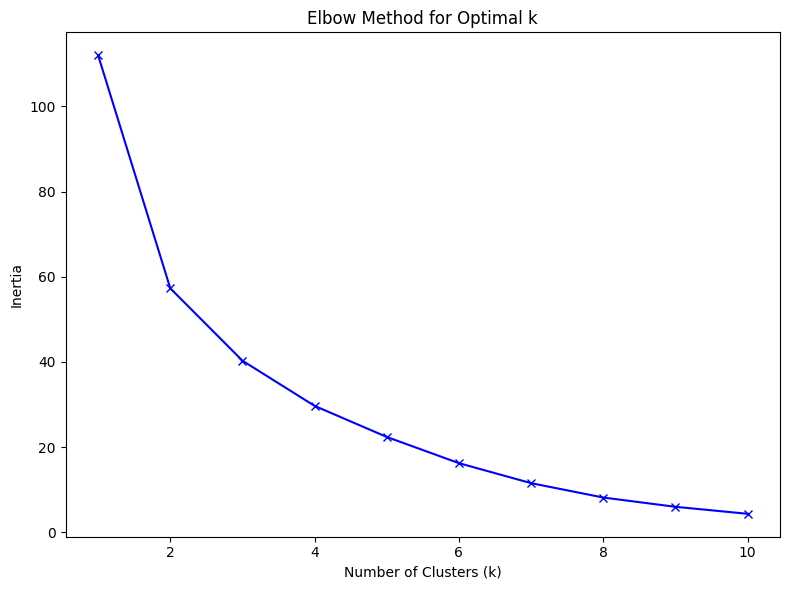

In [19]:
cleaned_data = pd.read_csv('data/decoded_features.csv')

features = cleaned_data.drop(columns=['Skill'])
# Fill NaN values with -1, as -1 was used to represent 'N/A' for categorical features
features_filled = features.fillna(-1)

scaler = StandardScaler()
features_normalized = scaler.fit_transform(features_filled)

inertia = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(features_normalized)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.tight_layout()
plt.show()

### 3.4 K-Means Clusters & Curriculum

In [20]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(features_normalized)
cleaned_data['Cluster'] = clusters

for cluster_id in range(optimal_k):
    print(f'Cluster {cluster_id}:')
    print(cleaned_data[cleaned_data['Cluster'] == cluster_id]['Skill'].tolist())
    print()

Cluster 0:
['Data Management', 'Big Data', 'Machine Learning', 'Project Management']

Cluster 1:
['Python', 'Excel', 'SQL', 'Modeling', 'Consulting', 'Creativity', 'Communication']

Cluster 2:
['Matlab']

Cluster 3:
['Negotiation', 'Teamwork']



### 3.5 PCA Scatterplot

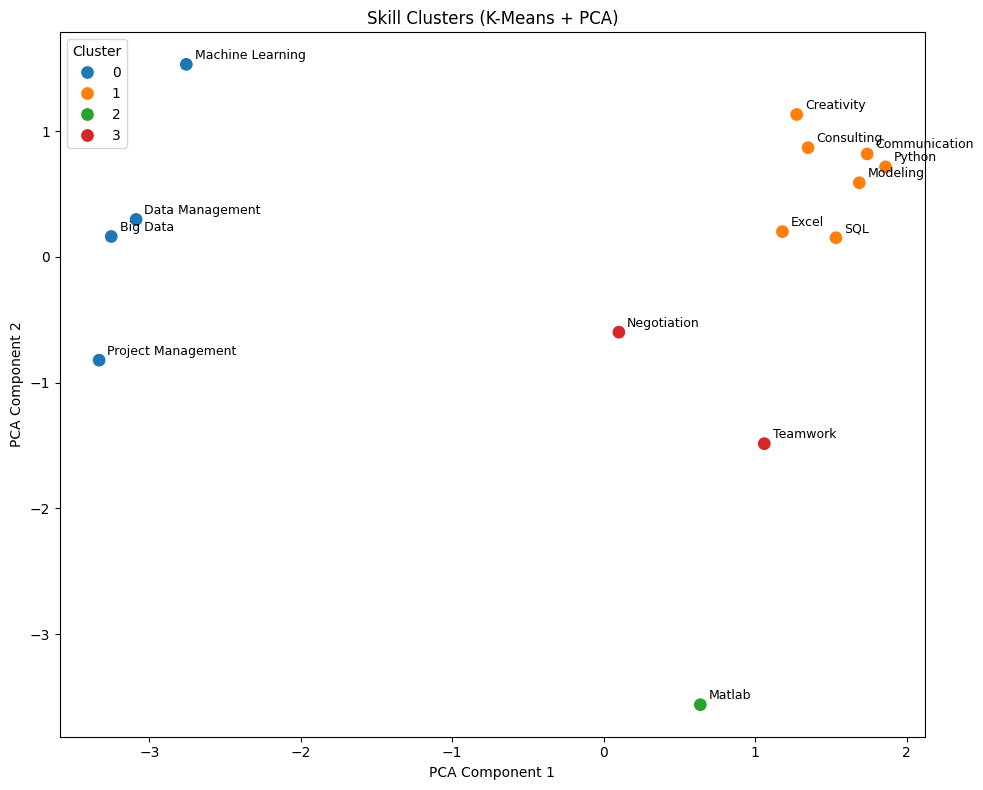

In [21]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(features_normalized)
cleaned_data['PCA1'] = reduced[:, 0]
cleaned_data['PCA2'] = reduced[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=cleaned_data, palette='tab10', s=100)
for _, row in cleaned_data.iterrows():
    plt.annotate(row['Skill'], (row['PCA1'], row['PCA2']), textcoords='offset points', xytext=(6, 4), fontsize=9)
plt.title('Skill Clusters (K-Means + PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## 4. Curriculum Generation via LLM

In [22]:
final_course_curriculum = {
    f'Course {i + 1}': cleaned_data[cleaned_data['Cluster'] == i]['Skill'].tolist()
    for i in range(optimal_k)
}

print('Final Course Curriculum:')
for course, skills in final_course_curriculum.items():
    print(f'  {course}: {", ".join(skills)}')

Final Course Curriculum:
  Course 1: Data Management, Big Data, Machine Learning, Project Management
  Course 2: Python, Excel, SQL, Modeling, Consulting, Creativity, Communication
  Course 3: Matlab
  Course 4: Negotiation, Teamwork


In [23]:
openai.api_key = os.getenv('OPENAI_API_KEY')

def query_chatgpt(prompt):
    try:
        response = openai.ChatCompletion.create(
            model='gpt-3.5-turbo',
            messages=[
                {'role': 'system', 'content': 'You are an expert data scientist and educator.'},
                {'role': 'user', 'content': prompt},
            ],
            temperature=0.3,
        )
        return response['choices'][0]['message']['content']
    except Exception as e:
        print(f'Error: {e}')
        return None

curriculum_prompt = f"""
You are an educational content designer. Based on the clustering results provided, write a short,
enticing description of the following course curriculum. Highlight why the courses would be
beneficial for students and how they relate to career goals:

{final_course_curriculum}
"""

similarity_prompt = f"""
You are a data scientist and educator. Analyze the clustering results below and describe the
similarities within each cluster. Highlight how the skills are related and why they were grouped:

{final_course_curriculum}
"""

course_description = query_chatgpt(curriculum_prompt)
cluster_similarity = query_chatgpt(similarity_prompt)

print('Course Description:')
print(course_description)
print('\nCluster Similarity Analysis:')
print(cluster_similarity)

Error: 

You tried to access openai.ChatCompletion, but this is no longer supported in openai>=1.0.0 - see the README at https://github.com/openai/openai-python for the API.

You can run `openai migrate` to automatically upgrade your codebase to use the 1.0.0 interface. 

Alternatively, you can pin your installation to the old version, e.g. `pip install openai==0.28`

A detailed migration guide is available here: https://github.com/openai/openai-python/discussions/742

Error: 

You tried to access openai.ChatCompletion, but this is no longer supported in openai>=1.0.0 - see the README at https://github.com/openai/openai-python for the API.

You can run `openai migrate` to automatically upgrade your codebase to use the 1.0.0 interface. 

Alternatively, you can pin your installation to the old version, e.g. `pip install openai==0.28`

A detailed migration guide is available here: https://github.com/openai/openai-python/discussions/742

Course Description:
None

Cluster Similarity Analysi

In [24]:
os.makedirs('output', exist_ok=True)

with open('output/course_description.txt', 'w') as f:
    f.write(course_description or '')

with open('output/cluster_similarity.txt', 'w') as f:
    f.write(cluster_similarity or '')

print('Outputs saved to output/')

Outputs saved to output/


## Conclusions

Analysis of **4,408 Indeed job postings** clustered 14 data science skills into four curriculum-ready groups using hierarchical and K-Means clustering (k=4):

| Course | Skills |
|--------|--------|
| **Data Infrastructure & ML** | Data Management, Big Data, Machine Learning, Project Management |
| **Core Analytics & Communication** | Python, Excel, SQL, Modeling, Consulting, Creativity, Communication |
| **Specialised Computation** | Matlab *(elective only)* |
| **Soft Skills** | Negotiation, Teamwork |

Three findings stand out from the data:

1. **Soft skills dominate frequency.** Creativity (3,078) and Communication (2,657) were mentioned more than any technical skill, including Python (1,901) and SQL (1,957).
2. **Python and SQL lead on salary.** Python (~$40K) and SQL (~$37K) showed the strongest salary associations, confirming their value as foundational technical skills.
3. **Matlab is isolated.** Its weak co-occurrence with all other skills marks it as a niche tool, suitable as an elective rather than a core requirement.

**Recommendation:** Prioritise the Core Analytics & Communication course as the centrepiece of any data science curriculum — it captures the broadest employer demand and reflects how technical and interpersonal skills are expected together in practice.